# Inspect cleaned graph JSONs

Visualize the per-node `trav_score` / `frontier_score` written by [`generate_cleaned_jsons.py`](generate_cleaned_jsons.py).

Pick a mission and scrub the frame slider. Each node from `graph_NNNNNN.json` is plotted on the matching RGB and colored by its score (viridis for traversability, magma for frontier). Nodes whose pixel landed off-image are skipped.

Set `CLEANED_ROOT` and `RGB_ROOT` below — they can point at the same directory if you ran the script with `--output-root` set to the dataset itself.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

RGB_ROOT     = Path('/home/rohang73/Desktop/longrange')
CLEANED_ROOT = Path('/home/rohang73/Desktop/longrange_explorfm_clean')

assert RGB_ROOT.is_dir(),     f'RGB root not found: {RGB_ROOT}'
assert CLEANED_ROOT.is_dir(), f'Cleaned root not found: {CLEANED_ROOT}'

In [2]:
def list_missions():
    return sorted(p.name for p in CLEANED_ROOT.iterdir()
                  if p.is_dir() and any(p.glob('graph_*.json')))

def list_frames(mission):
    return sorted(p.name for p in (CLEANED_ROOT / mission).glob('graph_*.json'))

def rgb_path_for(mission, graph_fname):
    idx = graph_fname.replace('graph_', '').replace('.json', '')
    return RGB_ROOT / mission / f'rgb_{idx}.png'

missions = list_missions()
assert missions, f'no cleaned missions under {CLEANED_ROOT}'
init_mission = missions[0]
print(f'{len(missions)} missions found, default: {init_mission}')

16 missions found, default: highrange_rgb_nav_graph_dataset_2024-10-01-11-47-44_mission


## Per-frame viewer

Three panels: raw RGB, nodes colored by `trav_score` (viridis), nodes colored by `frontier_score` (magma). Frontier nodes are drawn as `*`, free-space nodes as `o`. The label below the slider summarises score statistics for the current frame.

In [ ]:
current_frames = []

mission_dd = widgets.Dropdown(options=missions, value=init_mission,
                              description='Mission:',
                              layout=widgets.Layout(width='90%'),
                              style={'description_width': '90px'})
frame_sl = widgets.IntSlider(min=0, max=0, step=1, value=0,
                             description='Frame idx:',
                             continuous_update=False,
                             layout=widgets.Layout(width='90%'),
                             style={'description_width': '90px'})
label = widgets.Label(value='')
out = widgets.Output()

def collect(nodes, score_key):
    xs, ys, vals, types = [], [], [], []
    for n in nodes:
        v = n.get(score_key)
        if v is None:
            continue
        px, py = n['pixel']
        xs.append(px); ys.append(py); vals.append(v); types.append(n.get('type', ''))
    return np.array(xs), np.array(ys), np.array(vals), np.array(types)

def draw_panel(ax, img, xs, ys, vals, types, cmap, title):
    ax.imshow(img); ax.set_title(title); ax.axis('off')
    if len(xs) == 0:
        return
    norm = Normalize(vmin=0.0, vmax=1.0)
    is_frontier = types == 'frontier'
    if (~is_frontier).any():
        ax.scatter(xs[~is_frontier], ys[~is_frontier], c=vals[~is_frontier],
                   cmap=cmap, norm=norm, s=36, marker='o',
                   edgecolors='black', linewidths=0.6)
    if is_frontier.any():
        ax.scatter(xs[is_frontier], ys[is_frontier], c=vals[is_frontier],
                   cmap=cmap, norm=norm, s=70, marker='*',
                   edgecolors='black', linewidths=0.7)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)

def render():
    if not current_frames:
        return
    fname = current_frames[frame_sl.value]
    mission = mission_dd.value
    rgb_p = rgb_path_for(mission, fname)
    json_p = CLEANED_ROOT / mission / fname
    img_np = np.array(Image.open(rgb_p).convert('RGB'))
    with open(json_p) as f:
        data = json.load(f)
    nodes = data.get('nodes', [])

    xs_t, ys_t, vt, types_t = collect(nodes, 'trav_score')
    xs_f, ys_f, vf, types_f = collect(nodes, 'frontier_score')

    def stats(v):
        if len(v) == 0:
            return 'n=0'
        return f'n={len(v)} min={v.min():.2f} mean={v.mean():.2f} max={v.max():.2f}'
    label.value = (f'{fname}    {img_np.shape[1]}x{img_np.shape[0]}    '
                   f'frame {frame_sl.value+1}/{len(current_frames)}    '
                   f'trav: {stats(vt)}    frontier: {stats(vf)}')

    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(img_np); axes[0].set_title('RGB'); axes[0].axis('off')
        draw_panel(axes[1], img_np, xs_t, ys_t, vt, types_t, 'viridis',
                   f'trav_score (n={len(vt)})')
        draw_panel(axes[2], img_np, xs_f, ys_f, vf, types_f, 'magma',
                   f'frontier_score (n={len(vf)})')
        plt.tight_layout(); plt.show()

def on_mission_change(change):
    global current_frames
    current_frames = list_frames(change['new'])
    frame_sl.unobserve(on_frame_change, names='value')
    frame_sl.max = max(0, len(current_frames) - 1)
    frame_sl.value = 0
    frame_sl.observe(on_frame_change, names='value')
    render()

def on_frame_change(change):
    render()

current_frames = list_frames(init_mission)
frame_sl.max = max(0, len(current_frames) - 1)

mission_dd.observe(on_mission_change, names='value')
frame_sl.observe(on_frame_change, names='value')

display(widgets.VBox([mission_dd, frame_sl, label, out]))
render()

In [8]:
## Manual vs auto vs original — per-frame viewer
#
# Panel 1 — RGB + ALL original nodes from RGB_ROOT (unfiltered dataset).
# Panel 2 — Auto-cleaned: trav_score >= Trav thresh (kept green / removed red).
# Panel 3 — Manual-cleaned: your hand-edited kept (green) / removed (red).
#
# Frontier nodes = star marker; free-space nodes = circle marker.

MANUAL_ROOT = Path('/home/rohang73/Desktop/longrange-git/longrange')
assert MANUAL_ROOT.is_dir(), f'Manual root not found: {MANUAL_ROOT}'

def list_cmp_missions():
    auto_set   = {p.name for p in CLEANED_ROOT.iterdir() if p.is_dir()}
    manual_set = {p.name for p in MANUAL_ROOT.iterdir()  if p.is_dir()}
    return sorted(p.name for p in RGB_ROOT.iterdir()
                  if p.is_dir()
                  and p.name in auto_set
                  and p.name in manual_set
                  and any(p.glob('graph_*.json')))

def list_cmp_frames(mission):
    auto_files   = {p.name for p in (CLEANED_ROOT / mission).glob('graph_*.json')}
    manual_files = {p.name for p in (MANUAL_ROOT  / mission).glob('graph_*.json')}
    return sorted(p.name for p in (RGB_ROOT / mission).glob('graph_*.json')
                  if p.name in auto_files and p.name in manual_files)

cmp_missions = list_cmp_missions()
assert cmp_missions, 'no overlapping missions across RGB_ROOT / CLEANED_ROOT / MANUAL_ROOT'
print(f'{len(cmp_missions)} overlapping missions, default: {cmp_missions[0]}')

cmp_mission_dd = widgets.Dropdown(options=cmp_missions, value=cmp_missions[0],
                                  description='Mission:',
                                  layout=widgets.Layout(width='90%'),
                                  style={'description_width': '90px'})
cmp_frame_sl = widgets.IntSlider(min=0, max=0, step=1, value=0,
                                 description='Frame idx:',
                                 continuous_update=False,
                                 layout=widgets.Layout(width='70%'),
                                 style={'description_width': '90px'})
cmp_thresh_sl = widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5,
                                    description='Trav thresh:',
                                    continuous_update=False,
                                    layout=widgets.Layout(width='90%'),
                                    style={'description_width': '90px'})
cmp_prev_btn = widgets.Button(description='◀ Prev', layout=widgets.Layout(width='90px'))
cmp_next_btn = widgets.Button(description='Next ▶', layout=widgets.Layout(width='90px'))
cmp_label = widgets.Label(value='')
cmp_out = widgets.Output()
cmp_current_frames = []

def _scatter(ax, nodes_list, color, s_o=36, s_star=70):
    xs, ys, types = [], [], []
    for n in nodes_list:
        px, py = n['pixel']
        xs.append(px); ys.append(py); types.append(n.get('type', ''))
    if not xs:
        return
    xs, ys, types = np.array(xs), np.array(ys), np.array(types)
    is_f = types == 'frontier'
    if (~is_f).any():
        ax.scatter(xs[~is_f], ys[~is_f], s=s_o, c=color,
                   marker='o', edgecolors='black', linewidths=0.6)
    if is_f.any():
        ax.scatter(xs[is_f], ys[is_f], s=s_star, c=color,
                   marker='*', edgecolors='black', linewidths=0.7)

def cmp_render():
    if not cmp_current_frames:
        return
    fname   = cmp_current_frames[cmp_frame_sl.value]
    mission = cmp_mission_dd.value
    thresh  = cmp_thresh_sl.value
    idx     = fname.replace('graph_', '').replace('.json', '')

    img_np = np.array(Image.open(RGB_ROOT / mission / f'rgb_{idx}.png').convert('RGB'))

    orig_nodes     = json.load(open(RGB_ROOT    / mission / fname)).get('nodes', [])
    auto_nodes     = json.load(open(CLEANED_ROOT / mission / fname)).get('nodes', [])
    manual_data    = json.load(open(MANUAL_ROOT  / mission / fname))
    manual_kept    = manual_data.get('nodes', [])
    manual_removed = manual_data.get('removed_nodes', [])

    auto_kept    = [n for n in auto_nodes if n.get('trav_score', 0.0) >= thresh]
    auto_removed = [n for n in auto_nodes if n.get('trav_score', 0.0) <  thresh]

    mk_ids  = {n['id'] for n in manual_kept}
    ak_ids  = {n['id'] for n in auto_kept}
    all_ids = {n['id'] for n in orig_nodes}
    tp = len(mk_ids & ak_ids)
    fp = len(ak_ids - mk_ids)
    fn = len(mk_ids - ak_ids)
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)

    cmp_label.value = (
        f'{fname}  {img_np.shape[1]}×{img_np.shape[0]}  '
        f'frame {cmp_frame_sl.value+1}/{len(cmp_current_frames)}  '
        f'total={len(orig_nodes)}  manual_kept={len(manual_kept)}  '
        f'manual_removed={len(manual_removed)}  '
        f'auto_kept={len(auto_kept)} (T={thresh:.2f})  '
        f'P={prec:.2f}  R={rec:.2f}  F1={f1:.2f}'
    )

    with cmp_out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(21, 6))
        for a in axes:
            a.imshow(img_np); a.axis('off')

        _scatter(axes[0], orig_nodes, 'lime')
        axes[0].set_title(f'Original — all nodes (n={len(orig_nodes)})')

        _scatter(axes[1], auto_kept,    'lime')
        _scatter(axes[1], auto_removed, 'red')
        axes[1].set_title(
            f'Auto T≥{thresh:.2f} — kept (green, n={len(auto_kept)}) / '
            f'removed (red, n={len(auto_removed)})')

        _scatter(axes[2], manual_kept,    'lime')
        _scatter(axes[2], manual_removed, 'red')
        axes[2].set_title(
            f'Manual — kept (green, n={len(manual_kept)}) / '
            f'removed (red, n={len(manual_removed)})')

        plt.tight_layout(); plt.show()

def cmp_on_prev(b):
    if cmp_frame_sl.value > 0:
        cmp_frame_sl.value -= 1

def cmp_on_next(b):
    if cmp_frame_sl.value < cmp_frame_sl.max:
        cmp_frame_sl.value += 1

def cmp_on_mission_change(change):
    global cmp_current_frames
    cmp_current_frames = list_cmp_frames(change['new'])
    cmp_frame_sl.unobserve(cmp_on_frame_change, names='value')
    cmp_frame_sl.max = max(0, len(cmp_current_frames) - 1)
    cmp_frame_sl.value = 0
    cmp_frame_sl.observe(cmp_on_frame_change, names='value')
    cmp_render()

def cmp_on_frame_change(change):  cmp_render()
def cmp_on_thresh_change(change): cmp_render()

cmp_prev_btn.on_click(cmp_on_prev)
cmp_next_btn.on_click(cmp_on_next)

cmp_current_frames = list_cmp_frames(cmp_missions[0])
cmp_frame_sl.max = max(0, len(cmp_current_frames) - 1)

cmp_mission_dd.observe(cmp_on_mission_change, names='value')
cmp_frame_sl.observe(cmp_on_frame_change,   names='value')
cmp_thresh_sl.observe(cmp_on_thresh_change, names='value')

display(widgets.VBox([
    cmp_mission_dd,
    widgets.HBox([cmp_prev_btn, cmp_frame_sl, cmp_next_btn]),
    cmp_thresh_sl,
    cmp_label,
    cmp_out,
]))
cmp_render()

11 overlapping missions, default: highrange_rgb_nav_graph_dataset_2024-10-01-11-47-44_mission


Threshold: 0.50  (change STATS_THRESH = <value> and re-run to update)

                     frames    total      TP     FP      FN     TN  precision  recall     F1  agreement
mission                                                                                                
2024-10-01-11-47-44      85   102554   83104   3354    4190  11906      0.961   0.952  0.957      0.926
2024-10-01-12-00-49      94   132504  111023   4128   11482   5871      0.964   0.906  0.934      0.882
2024-11-02-17-10-25      76    37217   30444     73    4230   2470      0.998   0.878  0.934      0.884
2024-11-04-10-57-34      92   136519   91432   1661   35104   8322      0.982   0.723  0.833      0.731
2024-11-11-12-07-40     120    70327   39561    383   26687   3696      0.990   0.597  0.745      0.615
2024-11-11-12-42-47      57    14197   11305    265    2238    389      0.977   0.835  0.900      0.824
2024-11-11-16-14-23      69    66218   45690   1837    7183  11508      0.961   0.864  0.910     

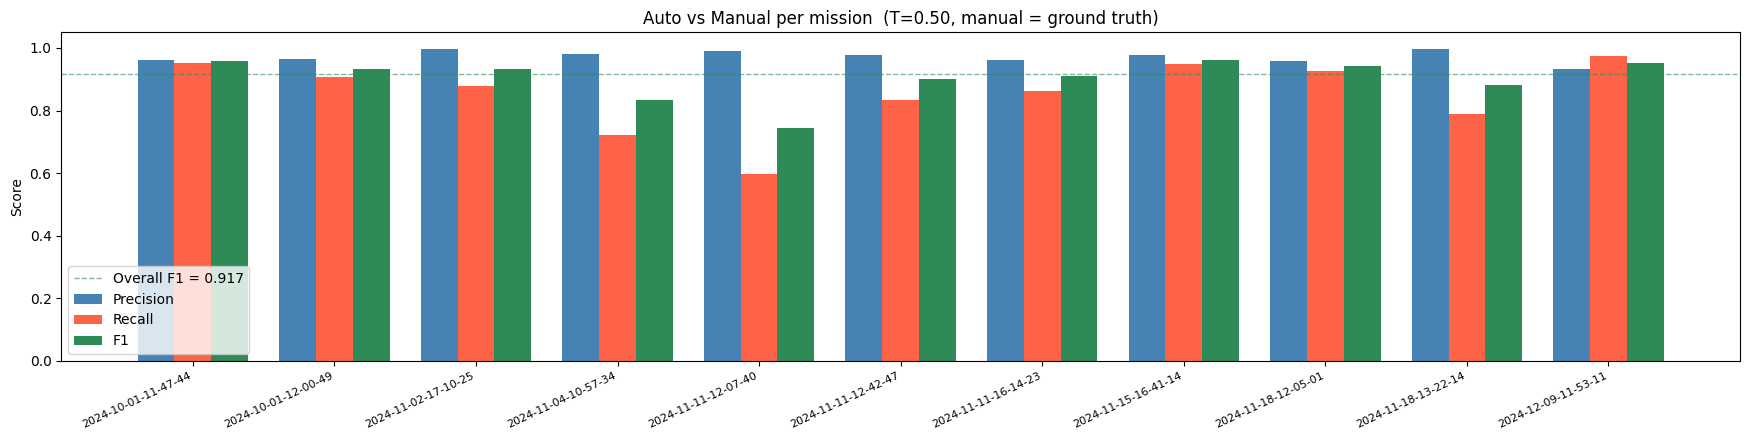

In [9]:
## Mission-level statistics — auto vs manual (ground truth)
#
# Aggregates TP/FP/FN/TN across every overlapping frame in each mission at a
# fixed threshold. Produces a table + bar chart of Precision / Recall / F1.
# Adjust STATS_THRESH to match whatever threshold you settled on above.

import pandas as pd

STATS_THRESH = cmp_thresh_sl.value   # reads the slider set in the viewer above; change if needed
print(f'Threshold: {STATS_THRESH:.2f}  (change STATS_THRESH = <value> and re-run to update)\n')

rows = []
for mission in cmp_missions:
    frames = list_cmp_frames(mission)
    tp = fp = fn = tn = 0
    for fname in frames:
        orig_nodes  = json.load(open(RGB_ROOT    / mission / fname)).get('nodes', [])
        auto_nodes  = json.load(open(CLEANED_ROOT / mission / fname)).get('nodes', [])
        manual_data = json.load(open(MANUAL_ROOT  / mission / fname))

        all_ids = {n['id'] for n in orig_nodes}
        mk_ids  = {n['id'] for n in manual_data.get('nodes', [])}
        ak_ids  = {n['id'] for n in auto_nodes if n.get('trav_score', 0.0) >= STATS_THRESH}

        tp += len(mk_ids & ak_ids)
        fp += len(ak_ids - mk_ids)
        fn += len(mk_ids - ak_ids)
        tn += len((all_ids - mk_ids) & (all_ids - ak_ids))

    total  = tp + fp + fn + tn
    prec   = tp / max(tp + fp, 1)
    rec    = tp / max(tp + fn, 1)
    f1     = 2 * prec * rec / max(prec + rec, 1e-9)
    agree  = (tp + tn) / max(total, 1)
    rows.append({
        'mission':   mission.replace('highrange_rgb_nav_graph_dataset_', '').replace('_mission', ''),
        'frames':    len(frames),
        'total':     total,
        'TP':        tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'precision': prec,
        'recall':    rec,
        'F1':        f1,
        'agreement': agree,
    })

# totals row
t = {k: sum(r[k] for r in rows) for k in ('frames', 'total', 'TP', 'FP', 'FN', 'TN')}
tp, fp, fn, tn = t['TP'], t['FP'], t['FN'], t['TN']
rows.append({
    'mission':   'TOTAL',
    **t,
    'precision': tp / max(tp + fp, 1),
    'recall':    tp / max(tp + fn, 1),
    'F1':        2*(tp/(max(tp+fp,1)))*(tp/(max(tp+fn,1))) / max((tp/(max(tp+fp,1)))+(tp/(max(tp+fn,1))), 1e-9),
    'agreement': (tp + tn) / max(tp + fp + fn + tn, 1),
})

df = pd.DataFrame(rows).set_index('mission')
df[['precision', 'recall', 'F1', 'agreement']] = df[['precision', 'recall', 'F1', 'agreement']].round(3)
print(df[['frames', 'total', 'TP', 'FP', 'FN', 'TN', 'precision', 'recall', 'F1', 'agreement']].to_string())

# --- bar chart (exclude TOTAL row) ---
plot_df = df.drop(index='TOTAL')
fig, ax = plt.subplots(figsize=(max(10, len(plot_df) * 1.6), 4.5))
x = np.arange(len(plot_df))
w = 0.26
ax.bar(x - w, plot_df['precision'], width=w, label='Precision', color='steelblue')
ax.bar(x,     plot_df['recall'],    width=w, label='Recall',    color='tomato')
ax.bar(x + w, plot_df['F1'],        width=w, label='F1',        color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title(f'Auto vs Manual per mission  (T={STATS_THRESH:.2f}, manual = ground truth)')
ax.legend()
ax.axhline(df.loc['TOTAL', 'F1'], color='seagreen', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Overall F1 = {df.loc["TOTAL", "F1"]:.3f}')
ax.legend()
plt.tight_layout(); plt.show()

## Mission-level score histograms

Aggregates `trav_score` / `frontier_score` across all nodes in the currently-selected mission. Useful for sanity-checking that the model's score distribution is sensible (e.g. trav scores skewed towards 1.0 for `free_space` nodes).

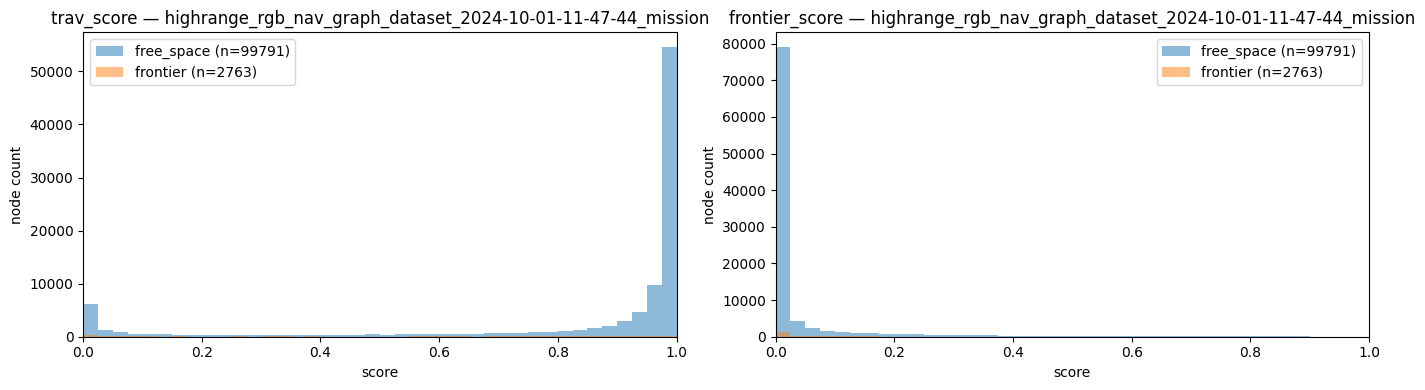

In [4]:
mission = mission_dd.value
trav_by_type = {'free_space': [], 'frontier': [], 'other': []}
front_by_type = {'free_space': [], 'frontier': [], 'other': []}
for fname in list_frames(mission):
    with open(CLEANED_ROOT / mission / fname) as f:
        for n in json.load(f).get('nodes', []):
            t = n.get('type', '')
            bucket = t if t in trav_by_type else 'other'
            if n.get('trav_score') is not None:
                trav_by_type[bucket].append(n['trav_score'])
            if n.get('frontier_score') is not None:
                front_by_type[bucket].append(n['frontier_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, scores, title in [
    (axes[0], trav_by_type,  f'trav_score — {mission}'),
    (axes[1], front_by_type, f'frontier_score — {mission}'),
]:
    for bucket, vals in scores.items():
        if vals:
            ax.hist(vals, bins=40, range=(0, 1), alpha=0.5,
                    label=f'{bucket} (n={len(vals)})')
    ax.set_xlim(0, 1); ax.set_xlabel('score'); ax.set_ylabel('node count')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()